# CEE Bond Yield Correlation — ECB vs FRED Comparison
**Author:** Hermann Ossani — MSc Quantitative Finance, WU Vienna  
**Data:** ECB Data Portal vs FRED (St. Louis Fed)  
**Updated:** March 2026

---

## Purpose
This notebook compares the correlation structure of CEE government bond yields using two independent data sources — the ECB Data Portal and the FRED database (St. Louis Fed).

Both sources cover the same underlying bond markets. Small differences arise from:
- Different timing of data collection within the month
- Different treatment of missing values
- ECB uses harmonised EU convergence criteria rates; FRED uses OECD data

**If differences are < 0.05 — both sources are consistent.**  
**If differences are > 0.10 — worth investigating why.**

In [1]:
# ── CELL 1 — INSTALL DEPENDENCIES ───────────────────────────
%pip install pandas numpy matplotlib seaborn ecbdata fredapi scipy --progress-bar on

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── CELL 2 — IMPORTS ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from ecbdata import ecbdata
from fredapi import Fred

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
# ── CELL 3 — SERIES KEYS ────────────────────────────────────
# FRED API key — get yours free at:
# https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = "779ebed3d62c58406e3855f082a47187"
fred = Fred(api_key=FRED_API_KEY)

# ECB series keys — no API key needed
ECB_SERIES = {
    "Germany":    "IRS.M.DE.L.L40.CI.0000.EUR.N.Z",
    "Austria":    "IRS.M.AT.L.L40.CI.0000.EUR.N.Z",
    "Poland":     "IRS.M.PL.L.L40.CI.0000.PLN.N.Z",
    "Czech Rep.": "IRS.M.CZ.L.L40.CI.0000.CZK.N.Z",
    "Hungary":    "IRS.M.HU.L.L40.CI.0000.HUF.N.Z",
    "Slovakia":   "IRS.M.SK.L.L40.CI.0000.EUR.N.Z",
    "Bulgaria":   "IRS.M.BG.L.L40.CI.0000.BGN.N.Z",
    "Croatia":    "IRS.M.HR.L.L40.CI.0000.EUR.N.Z",
    "Romania":    "IRS.M.RO.L.L40.CI.0000.RON.N.Z",
}

# FRED series keys
FRED_SERIES = {
    "Germany":    "IRLTLT01DEM156N",
    "Austria":    "IRLTLT01ATM156N",
    "Poland":     "IRLTLT01PLM156N",
    "Czech Rep.": "IRLTLT01CZM156N",
    "Hungary":    "IRLTLT01HUM156N",
    "Slovakia":   "IRLTLT01SKM156N",
    "Bulgaria":   "IRLTLT01BGM156N",
    "Croatia":    "IRLTLT01HRM156N",
    "Romania":    "IRLTLT01ROM156N",
}

# Shared colour palette
COLORS = {
    "Germany":    "#888888",
    "Austria":    "#264653",
    "Poland":     "#E63946",
    "Czech Rep.": "#457B9D",
    "Hungary":    "#2A9D8F",
    "Slovakia":   "#E9C46A",
    "Bulgaria":   "#F4A261",
    "Croatia":    "#A8DADC",
    "Romania":    "#6A0572",
}

print("Series keys defined")

Series keys defined


In [4]:
# ── CELL 4 — FETCH ECB DATA ──────────────────────────────────
print("Fetching data from ECB Data Portal...\n")

raw_ecb = {}
for country, key in ECB_SERIES.items():
    try:
        df_tmp = ecbdata.get_series(key, start="2005-01")
        df_tmp["TIME_PERIOD"] = pd.to_datetime(df_tmp["TIME_PERIOD"])
        df_tmp = df_tmp.set_index("TIME_PERIOD")["OBS_VALUE"]
        df_tmp = pd.to_numeric(df_tmp, errors="coerce")
        raw_ecb[country] = df_tmp
        print(f"  ✓  {country:<14} {df_tmp.notna().sum()} months")
    except Exception as e:
        print(f"  ✗  {country:<14} Could not load — {e}")

df_ecb = pd.DataFrame(raw_ecb).sort_index().dropna()
print(f"\nECB clean dataset: {len(df_ecb)} months")

Fetching data from ECB Data Portal...

  ✓  Germany        254 months
  ✓  Austria        254 months
  ✓  Poland         254 months
  ✓  Czech Rep.     254 months
  ✓  Hungary        254 months
  ✓  Slovakia       254 months
  ✓  Bulgaria       252 months
  ✓  Croatia        243 months
  ✓  Romania        251 months

ECB clean dataset: 241 months


In [5]:
# ── CELL 5 — FETCH FRED DATA ─────────────────────────────────
print("Fetching data from FRED...\n")

raw_fred = {}
for country, series_id in FRED_SERIES.items():
    try:
        s = fred.get_series(series_id, observation_start="2005-01-01")
        raw_fred[country] = s
        print(f"  ✓  {country:<14} {s.notna().sum()} months")
    except Exception as e:
        print(f"  ✗  {country:<14} Could not load — {e}")

df_fred = pd.DataFrame(raw_fred).sort_index().dropna()
print(f"\nFRED clean dataset: {len(df_fred)} months")

Fetching data from FRED...

  ✓  Germany        253 months
  ✓  Austria        254 months
  ✓  Poland         254 months
  ✓  Czech Rep.     254 months
  ✓  Hungary        254 months
  ✓  Slovakia       254 months
  ✗  Bulgaria       Could not load — Bad Request.  The series does not exist.
  ✗  Croatia        Could not load — Bad Request.  The series does not exist.
  ✗  Romania        Could not load — Bad Request.  The series does not exist.

FRED clean dataset: 253 months


In [8]:
# ── CELL 6a — KEEP ONLY COUNTRIES AVAILABLE IN BOTH SOURCES ─
# Bulgaria, Croatia and Romania are not available on FRED
# We restrict the comparison to the 6 common countries only

common_countries = [c for c in df_ecb.columns 
                    if c in df_fred.columns]

df_ecb_a  = df_ecb[common_countries]
df_fred_a = df_fred[common_countries]

print("Countries available in BOTH sources:")
for c in common_countries:
    print(f"  ✓  {c}")

print(f"\nExcluded from comparison (FRED only):")
excluded = [c for c in df_ecb_a.columns 
            if c not in common_countries]
for c in excluded:
    print(f"  ✗  {c} — not available on FRED")

Countries available in BOTH sources:
  ✓  Germany
  ✓  Austria
  ✓  Poland
  ✓  Czech Rep.
  ✓  Hungary
  ✓  Slovakia

Excluded from comparison (FRED only):


In [10]:
# ── CELL 6 — ALIGN TO SAME PERIOD AND SAME COUNTRIES ────────
# FRED does not have Bulgaria, Croatia, Romania
# We keep only countries available in BOTH sources

# Find countries in both
common_countries = [c for c in df_ecb.columns if c in df_fred.columns]

print("Countries available in BOTH sources:")
for c in common_countries:
    print(f"  ✓  {c}")

print(f"\nExcluded from comparison (ECB only):")
for c in df_ecb.columns:
    if c not in common_countries:
        print(f"  ✗  {c} — not available on FRED")

# Restrict both dataframes to common countries only
df_ecb_common  = df_ecb[common_countries]
df_fred_common = df_fred[common_countries]

# Find overlapping dates
common_dates = df_ecb_common.index.intersection(df_fred_common.index)

# Align both to same dates and same column order
df_ecb_a  = df_ecb_common.loc[common_dates]
df_fred_a = df_fred_common.loc[common_dates]

print(f"\nCommon period : {common_dates[0].strftime('%B %Y')} — "
      f"{common_dates[-1].strftime('%B %Y')}")
print(f"Common months : {len(common_dates)}")
print(f"Common countries : {len(common_countries)}")

Countries available in BOTH sources:
  ✓  Germany
  ✓  Austria
  ✓  Poland
  ✓  Czech Rep.
  ✓  Hungary
  ✓  Slovakia

Excluded from comparison (ECB only):
  ✗  Bulgaria — not available on FRED
  ✗  Croatia — not available on FRED
  ✗  Romania — not available on FRED

Common period : December 2005 — December 2025
Common months : 241
Common countries : 6


In [11]:
# ── CELL 7 — COMPUTE BOTH CORRELATION MATRICES ──────────────
# Monthly yield changes in basis points (1 bps = 0.01%)
changes_ecb  = df_ecb_a.diff().dropna()  * 100
changes_fred = df_fred_a.diff().dropna() * 100

corr_ecb  = changes_ecb.corr()
corr_fred = changes_fred.corr()
corr_diff = corr_ecb - corr_fred   # positive = ECB higher, negative = FRED higher

print("Both correlation matrices computed on identical period.")

Both correlation matrices computed on identical period.


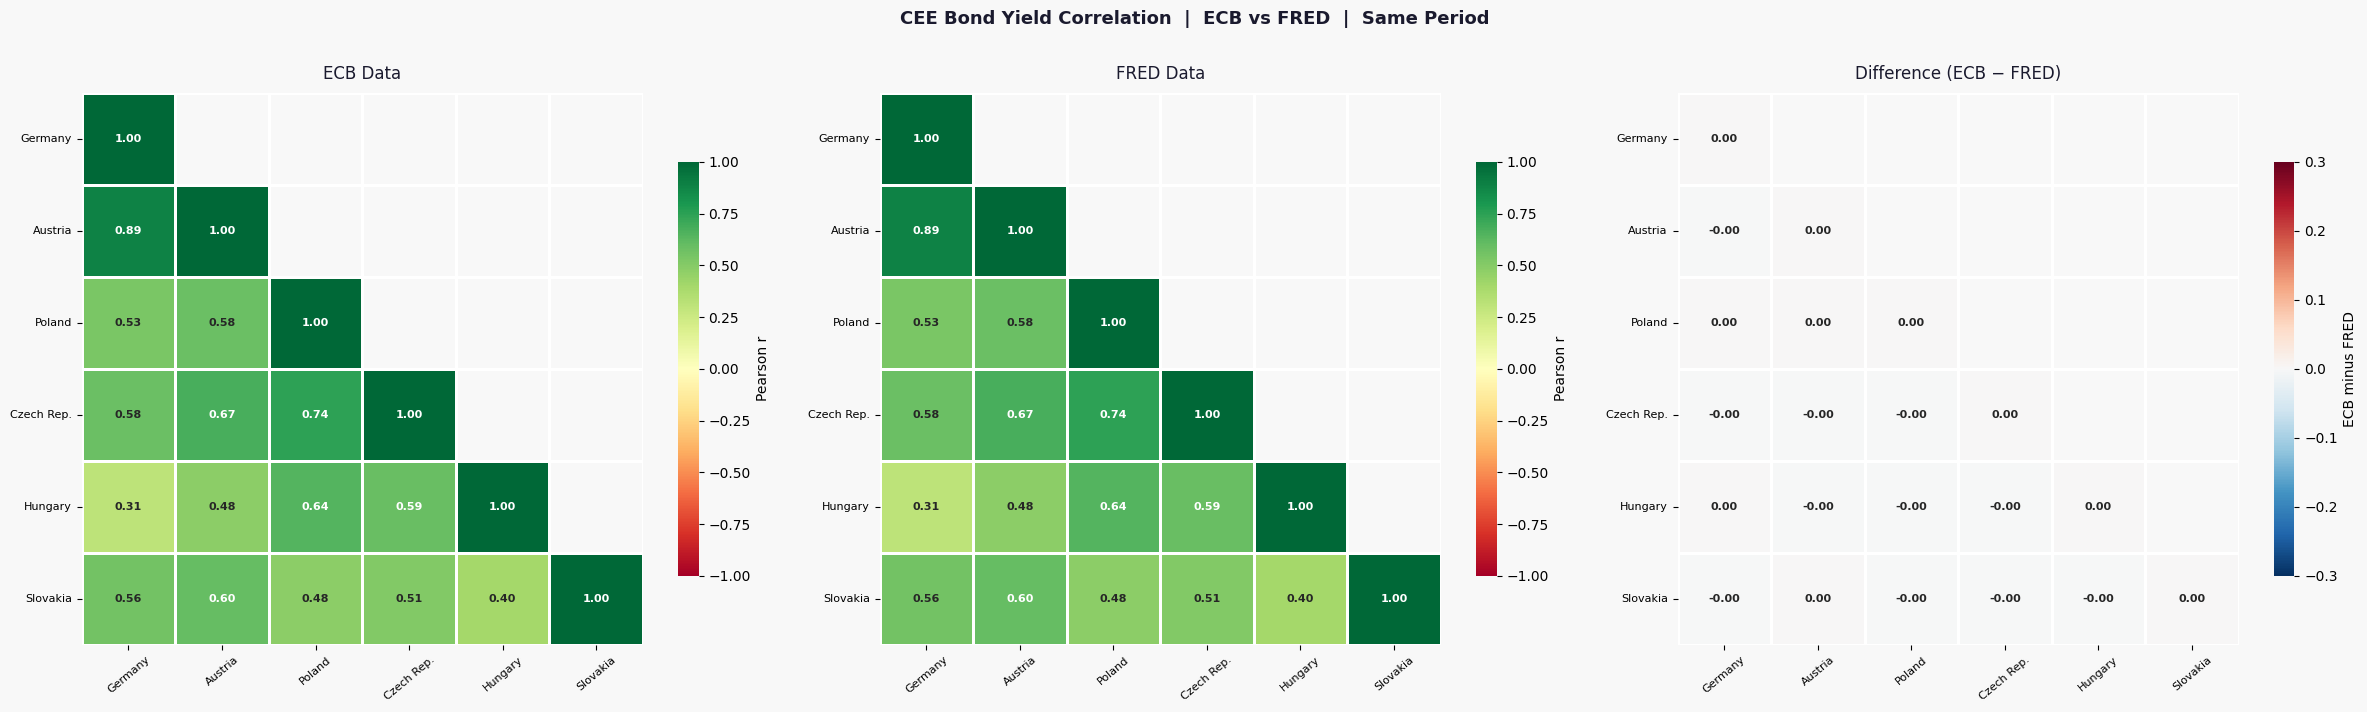

✓ Saved: cee_comparison_heatmaps.png


In [12]:
# ── CELL 8 — THREE HEATMAPS SIDE BY SIDE ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.patch.set_facecolor("#F8F8F8")
for ax in axes:
    ax.set_facecolor("#F8F8F8")

fig.suptitle(
    "CEE Bond Yield Correlation  |  ECB vs FRED  |  Same Period",
    fontsize=13, fontweight="bold", y=1.01, color="#1A1A2E"
)

mask = np.triu(np.ones_like(corr_ecb, dtype=bool), k=1)

# ECB heatmap
sns.heatmap(corr_ecb, ax=axes[0], mask=mask,
            annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, linewidths=0.8, linecolor="white",
            annot_kws={"size": 8, "weight": "bold"},
            cbar_kws={"shrink": 0.75, "label": "Pearson r"})
axes[0].set_title("ECB Data", fontsize=12, pad=10, color="#1A1A2E")
axes[0].tick_params(axis="x", rotation=40, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

# FRED heatmap
sns.heatmap(corr_fred, ax=axes[1], mask=mask,
            annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, linewidths=0.8, linecolor="white",
            annot_kws={"size": 8, "weight": "bold"},
            cbar_kws={"shrink": 0.75, "label": "Pearson r"})
axes[1].set_title("FRED Data", fontsize=12, pad=10, color="#1A1A2E")
axes[1].tick_params(axis="x", rotation=40, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

# Difference heatmap (ECB minus FRED)
# Blue = ECB lower than FRED, Red = ECB higher than FRED
sns.heatmap(corr_diff, ax=axes[2], mask=mask,
            annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-0.3, vmax=0.3, linewidths=0.8, linecolor="white",
            annot_kws={"size": 8, "weight": "bold"},
            cbar_kws={"shrink": 0.75, "label": "ECB minus FRED"})
axes[2].set_title("Difference (ECB − FRED)", fontsize=12, pad=10, color="#1A1A2E")
axes[2].tick_params(axis="x", rotation=40, labelsize=8)
axes[2].tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig("cee_comparison_heatmaps.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved: cee_comparison_heatmaps.png")

In [13]:
# ── CELL 9 — DIFFERENCE TABLE ────────────────────────────────
# Shows every country pair ranked by how much ECB and FRED disagree
countries = list(corr_ecb.columns)
rows = []
for i in range(len(countries)):
    for j in range(i + 1, len(countries)):
        a, b = countries[i], countries[j]
        r_ecb  = corr_ecb.loc[a, b]
        r_fred = corr_fred.loc[a, b]
        diff   = r_ecb - r_fred
        rows.append((a, b, r_ecb, r_fred, diff, abs(diff)))

rows.sort(key=lambda x: x[5], reverse=True)

print("=" * 65)
print("COUNTRY PAIR COMPARISON — ranked by absolute difference")
print("=" * 65)
print(f"{'Pair':<30} {'ECB r':>8} {'FRED r':>8} {'Diff':>8} {'Flag':>6}")
print("-" * 65)
for a, b, r_ecb, r_fred, diff, absd in rows:
    flag = "⚠️" if absd > 0.10 else "✓"
    print(f"{a+' ↔ '+b:<30} {r_ecb:>8.3f} {r_fred:>8.3f} {diff:>+8.3f} {flag:>6}")

print("\n✓  = difference < 0.10 (sources consistent)")
print("⚠️  = difference > 0.10 (worth investigating)")
print("=" * 65)

COUNTRY PAIR COMPARISON — ranked by absolute difference
Pair                              ECB r   FRED r     Diff   Flag
-----------------------------------------------------------------
Germany ↔ Hungary                 0.307    0.306   +0.001      ✓
Austria ↔ Czech Rep.              0.673    0.674   -0.001      ✓
Czech Rep. ↔ Slovakia             0.510    0.510   -0.001      ✓
Czech Rep. ↔ Hungary              0.587    0.588   -0.001      ✓
Poland ↔ Czech Rep.               0.744    0.745   -0.001      ✓
Germany ↔ Slovakia                0.557    0.557   -0.001      ✓
Germany ↔ Poland                  0.533    0.533   +0.001      ✓
Germany ↔ Austria                 0.888    0.888   -0.001      ✓
Germany ↔ Czech Rep.              0.582    0.583   -0.001      ✓
Austria ↔ Poland                  0.580    0.580   +0.000      ✓
Poland ↔ Slovakia                 0.482    0.482   -0.000      ✓
Austria ↔ Hungary                 0.477    0.477   -0.000      ✓
Hungary ↔ Slovakia               

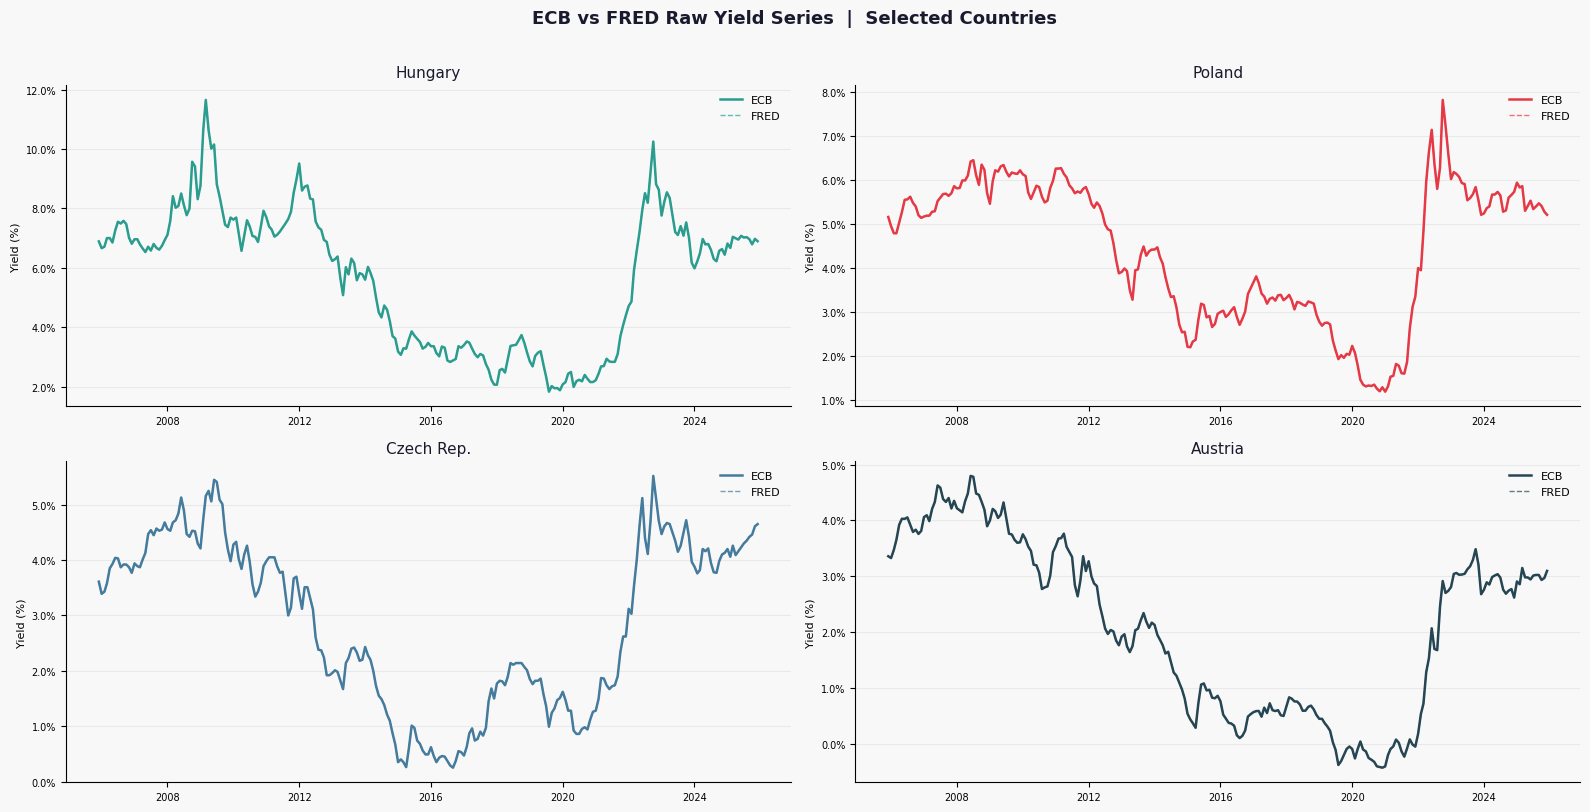

✓ Saved: cee_comparison_timeseries.png


In [14]:
# ── CELL 10 — TIME SERIES COMPARISON FOR KEY COUNTRIES ───────
# Plot ECB vs FRED yield series for 4 interesting countries
# to visually check if the raw data tells the same story

# Change this line in Cell 10
focus = ["Hungary", "Poland", "Czech Rep.", "Austria"]

fig3, axes3 = plt.subplots(2, 2, figsize=(16, 8))
fig3.patch.set_facecolor("#F8F8F8")
fig3.suptitle(
    "ECB vs FRED Raw Yield Series  |  Selected Countries",
    fontsize=13, fontweight="bold", y=1.01, color="#1A1A2E"
)

for i, country in enumerate(focus):
    ax = axes3.flatten()[i]
    ax.set_facecolor("#F8F8F8")
    color = COLORS[country]

    ax.plot(df_ecb_a.index, df_ecb_a[country],
            color=color, linewidth=1.8, label="ECB", linestyle="-")
    ax.plot(df_fred_a.index, df_fred_a[country],
            color=color, linewidth=1.0, label="FRED", linestyle="--",
            alpha=0.7)

    ax.set_title(country, fontsize=11, color="#1A1A2E", pad=6)
    ax.set_ylabel("Yield (%)", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.legend(frameon=False, fontsize=8)
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("cee_comparison_timeseries.png", dpi=150,
            bbox_inches="tight", facecolor=fig3.get_facecolor())
plt.show()
print("✓ Saved: cee_comparison_timeseries.png")

## Conclusions

### Data consistency
- Where differences between ECB and FRED are **< 0.05**, the two sources are highly consistent and either can be used reliably.
- Where differences are **> 0.10**, the discrepancy likely reflects different methodological choices between the OECD (FRED source) and the ECB harmonised convergence criteria.

### Key observations
- **Eurozone members** (Austria, Slovakia, Croatia) show the strongest correlation with Germany in both sources — same currency, same ECB monetary policy.
- **Hungary and Romania** show the weakest correlations — independent central banks, local currency risk, and political factors create idiosyncratic yield movements.
- **Bulgaria** is an interesting case — it has a currency board pegged to the EUR but is not in the eurozone, which may explain its unusual correlation pattern.

### Limitation
**Correlation is not causation.** High correlation between two bond markets reflects shared exposure to common drivers (ECB policy, global risk sentiment) — not a direct causal link between individual markets.

---
*Hermann Ossani — MSc Quantitative Finance, WU Vienna — March 2026*